<a href="https://colab.research.google.com/github/laceywang11/MSSP6070/blob/main/Week_11_Participation_Exercise_Lacey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Use Google Colabs and Python to visualize California's Congressional Districts**



In [1]:
!pip install geopandas

import geopandas as gp
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving california-congressional-districts.geojson to california-congressional-districts.geojson


In [3]:
cong = gp.read_file('california-congressional-districts.geojson')
cong.head()

,Name,description,descriptio,geometry
0,01,None,,"MULTIPOLYGON (((-120.07192 41.99495, -120.0010..."
1,02,None,,"MULTIPOLYGON (((-123.69821 41.81719, -123.6967..."
2,03,None,,"MULTIPOLYGON (((-121.667 39.30511, -121.63015 ..."
3,04,None,,"MULTIPOLYGON (((-120.37731 37.61679, -120.3823..."
4,05,None,,"MULTIPOLYGON (((-122.16384 38.64288, -122.1659..."


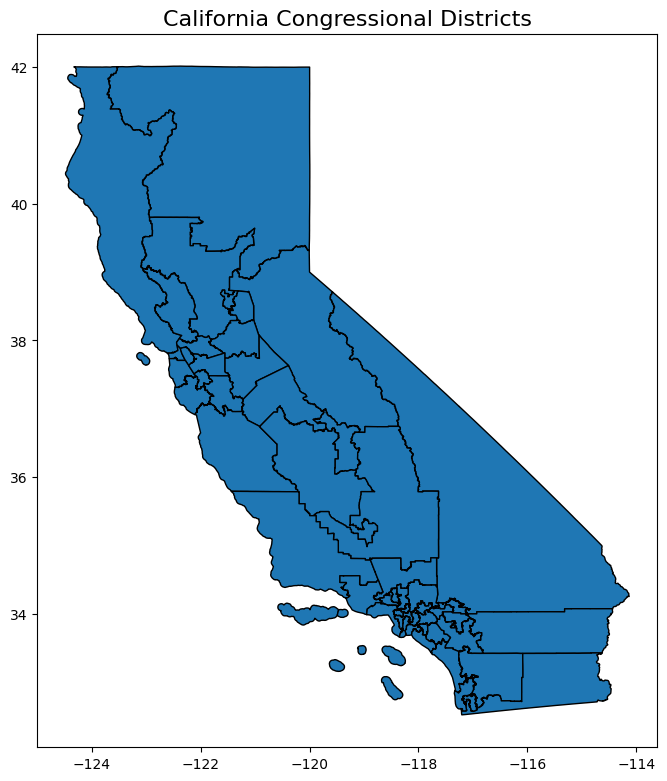

In [4]:
ax = cong.plot(figsize=(8, 12), edgecolor='black')
ax.set_title('California Congressional Districts', fontsize=16)
plt.show()

# **Overlay the Population of the California Legislative districts on the congressional districts**

In [5]:
from google.colab import files
uploaded = files.upload()

Saving CA_Legislative_Districts.csv to CA_Legislative_Districts.csv


In [7]:
leg = pd.read_csv('CA_Legislative_Districts.csv')
leg.head()
leg.columns

Index(['OBJECTID', 'ID', 'AREA', 'DISTRICT', 'MEMBERS', 'NAME', 'POPULATION',
       'CVAP_19', 'HSP_CVAP_1', 'DOJ_NH_BLK', 'DOJ_NH_ASN', 'NH_WHT_CVA',
       'IDEAL_VALU', 'DEVIATION', 'F_DEVIATIO', 'MULTIPLE_F', 'F_CVAP_19',
       'F_HSP_CVAP', 'F_DOJ_NH_B', 'F_DOJ_NH_A', 'F_NH_WHT_C', 'DISTRICT_L',
       'DISTRICT_N', 'SHAPE_Length', 'SHAPE_Area'],
      dtype='object')

In [8]:
cong['Name'] = cong['Name'].astype('float64')
leg['DISTRICT_N'] = leg['DISTRICT_N'].astype('float64')

In [10]:
cong['Name'].describe()

,Name
count,53.000000
mean,27.000000
std,15.443445
min,1.000000
25%,14.000000
50%,27.000000
75%,40.000000
max,53.000000


In [11]:
leg['DISTRICT_N'].describe()

,DISTRICT_N
count,52.000000
mean,26.500000
std,15.154757
min,1.000000
25%,13.750000
50%,26.500000
75%,39.250000
max,52.000000


In [13]:
districts = cong.merge(
    leg,
    how='left',
    left_on='Name',
    right_on='DISTRICT_N'
)
districts.head()

,Name,description,descriptio,geometry,OBJECTID,ID,AREA,DISTRICT,MEMBERS,NAME,...,MULTIPLE_F,F_CVAP_19,F_HSP_CVAP,F_DOJ_NH_B,F_DOJ_NH_A,F_NH_WHT_C,DISTRICT_L,DISTRICT_N,SHAPE_Length,SHAPE_Area
0,1.0,None,,"MULTIPOLYGON (((-120.07192 41.99495, -120.0010...",1.0,1.0,27014.63,1.0,1.0,MTCAP,...,1|0,0.7226,0.1403,0.0199,0.0475,0.7507,1|0%,1.0,2.633906e+06,1.222952e+11
1,2.0,None,,"MULTIPOLYGON (((-123.69821 41.81719, -123.6967...",12.0,12.0,14613.65,2.0,1.0,NOCST,...,2|1,0.7326,0.1095,0.0177,0.0426,0.7912,2|0%,2.0,2.160288e+06,6.486752e+10
2,3.0,None,,"MULTIPOLYGON (((-121.667 39.30511, -121.63015 ...",23.0,23.0,22035.87,3.0,1.0,YUBA,...,3|-1,0.7229,0.1015,0.0153,0.0587,0.7984,3|-0%,3.0,2.954865e+06,9.186026e+10
3,4.0,None,,"MULTIPOLYGON (((-120.37731 37.61679, -120.3823...",34.0,34.0,3923.91,4.0,1.0,FTHLL,...,4|-1,0.6972,0.1995,0.0325,0.0785,0.6656,4|-0%,4.0,1.090719e+06,1.673268e+10
4,5.0,None,,"MULTIPOLYGON (((-122.16384 38.64288, -122.1659...",45.0,45.0,9962.22,5.0,1.0,NEBAY,...,5|-1,0.7192,0.1814,0.0229,0.0565,0.7132,5|-0%,5.0,1.771074e+06,4.132481e+10


In [14]:
districts['POPULATION'].describe()

,POPULATION
count,52.000000
mean,760066.096154
std,0.773574
min,760065.000000
25%,760065.750000
50%,760066.000000
75%,760067.000000
max,760067.000000


In [15]:
districts['POPULATION'].isna().sum()

np.int64(1)

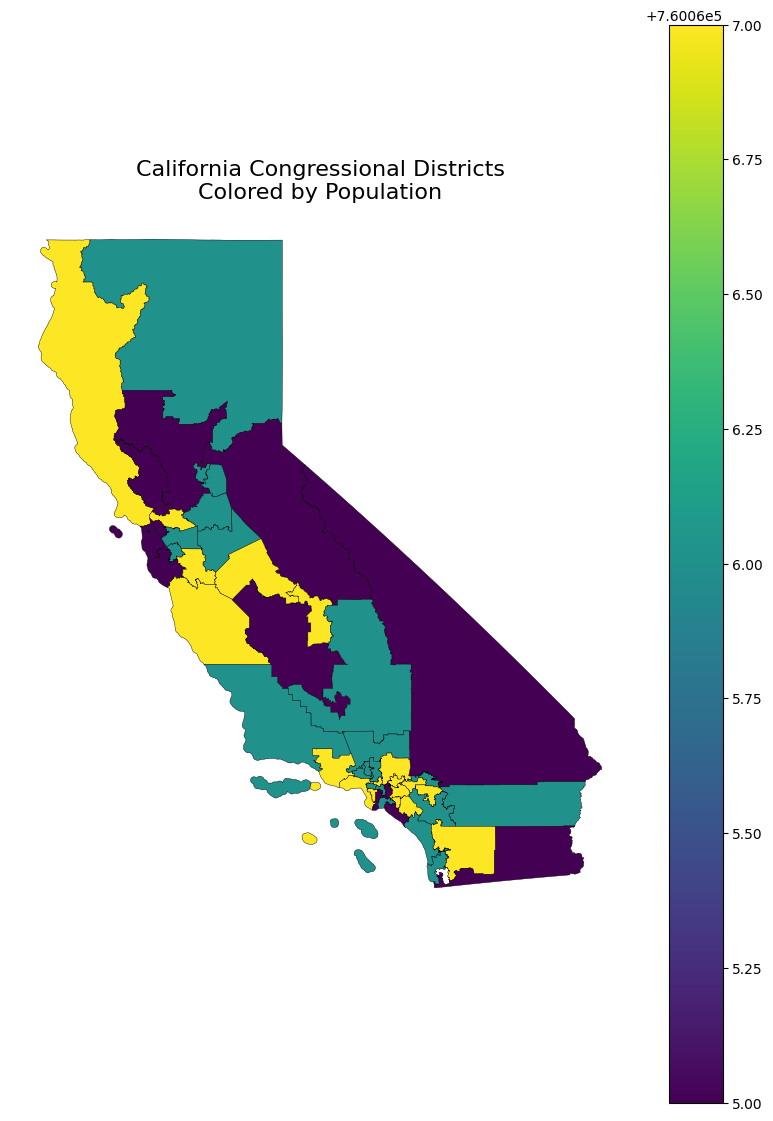

In [17]:
fig, ax = plt.subplots(figsize=(10, 14))
districts.plot(
    column='POPULATION',
    cmap='viridis',
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title('California Congressional Districts\nColored by Population', fontsize=16)
ax.set_axis_off()
plt.show()

In [18]:
fig.savefig('california_congressional_population_map.pdf', bbox_inches='tight')